In [1]:
from google.colab import files
uploaded = files.upload()


Saving CMAPSSData.zip to CMAPSSData.zip


In [2]:
import zipfile, os

zip_path = next(iter(uploaded))
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall("data")

os.listdir("data")


['RUL_FD001.txt',
 'Damage Propagation Modeling.pdf',
 'train_FD001.txt',
 'RUL_FD004.txt',
 'RUL_FD002.txt',
 'train_FD003.txt',
 'train_FD002.txt',
 'test_FD004.txt',
 'test_FD001.txt',
 'readme.txt',
 'test_FD003.txt',
 'test_FD002.txt',
 'RUL_FD003.txt',
 'train_FD004.txt']

In [3]:
!pip install torch torchvision torchaudio --quiet

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [4]:
TRAIN_PATH = "data/train_FD004.txt"
TEST_PATH  = "data/test_FD004.txt"
RUL_PATH   = "data/RUL_FD004.txt"

SEQ_LEN = 30
STEP = 1
BATCH_SIZE = 64
LR = 1e-3
EPOCHS = 100
PATIENCE = 10
RUL_CLIP = 130   # clip RUL to stabilize training

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

torch.manual_seed(42)
np.random.seed(42)


Using device: cpu


In [5]:
train_df = pd.read_csv(TRAIN_PATH, sep=" ", header=None).dropna(axis=1, how="all")
test_df  = pd.read_csv(TEST_PATH,  sep=" ", header=None).dropna(axis=1, how="all")
rul_df   = pd.read_csv(RUL_PATH,   sep=" ", header=None)

cols = ["unit", "cycle"] + [f"op_setting_{i}" for i in range(1,4)] + [f"sensor_{i}" for i in range(1,22)]
train_df = train_df.iloc[:, :len(cols)]
test_df  = test_df.iloc[:, :len(cols)]
train_df.columns = cols
test_df.columns  = cols

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)


Train shape: (61249, 26)
Test shape : (41214, 26)


In [6]:
train_max = train_df.groupby("unit")["cycle"].max().to_dict()
train_df["RUL"] = train_df.apply(lambda r: train_max[r["unit"]] - r["cycle"], axis=1)
train_df["RUL"] = train_df["RUL"].clip(upper=RUL_CLIP)

test_rul_map = {uid:int(r) for uid,r in zip(sorted(test_df["unit"].unique()), rul_df[0])}

print("Computed RUL for training and test maps ready.")


Computed RUL for training and test maps ready.


In [7]:
# Option B - recommended FD004 sensor set
selected_features = [
    "op_setting_1","op_setting_2","op_setting_3",
    "sensor_1","sensor_2","sensor_3","sensor_4",
    "sensor_6","sensor_7","sensor_8","sensor_9",
    "sensor_10","sensor_11","sensor_12","sensor_13",
    "sensor_14","sensor_15","sensor_17","sensor_20"
]

# keep unit and cycle + selected features (+ RUL for train)
train_df = train_df[["unit","cycle"] + selected_features + ["RUL"]]
test_df  = test_df [["unit","cycle"] + selected_features]

scaler = StandardScaler()
train_df[selected_features] = scaler.fit_transform(train_df[selected_features])
test_df[selected_features]  = scaler.transform(test_df[selected_features])

print("Selected features:", selected_features)
print("After scaling: train shape", train_df.shape, " test shape", test_df.shape)


Selected features: ['op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20']
After scaling: train shape (61249, 22)  test shape (41214, 21)


In [8]:
def make_sequences(df, units, seq_len):
    X, y = [], []
    for uid in units:
        temp = df[df["unit"] == uid].reset_index(drop=True)
        feats = temp[selected_features].values
        rul   = temp["RUL"].values
        L = len(temp)

        # create rolling sequences (step controlled by STEP)
        for i in range(0, L - seq_len + 1, STEP):
            X.append(feats[i:i+seq_len])
            y.append(rul[i+seq_len-1])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

units = sorted(train_df["unit"].unique())
# For FD004 (248 engines) use around 200 for training, rest for val
train_units = units[:200]
val_units = units[200:]

X_train, y_train = make_sequences(train_df, train_units, SEQ_LEN)
X_val,   y_val   = make_sequences(train_df, val_units,   SEQ_LEN)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "y_val  :", y_val.shape)


X_train: (43497, 30, 19) y_train: (43497,)
X_val  : (10531, 30, 19) y_val  : (10531,)


In [9]:
def make_test_windows(df, rul_map, seq_len):
    X, y = [], []
    units = sorted(df["unit"].unique())

    for uid in units:
        temp = df[df["unit"] == uid].reset_index(drop=True)
        feats = temp[selected_features].values

        if len(feats) < seq_len:
            pad = np.repeat(feats[0:1], seq_len - len(feats), axis=0)
            feats = np.vstack([pad, feats])
        else:
            feats = feats[-seq_len:]

        X.append(feats)
        y.append(min(rul_map[uid], RUL_CLIP))

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), units

X_test, y_test, test_units = make_test_windows(test_df, test_rul_map, SEQ_LEN)
print("X_test:", X_test.shape, "y_test:", y_test.shape)


X_test: (248, 30, 19) y_test: (248,)


In [10]:
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader = DataLoader(SeqDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(SeqDataset(X_val, y_val), batch_size=BATCH_SIZE)
test_loader  = DataLoader(SeqDataset(X_test, y_test), batch_size=BATCH_SIZE)

print("DataLoaders created. Train batches:", len(train_loader))


DataLoaders created. Train batches: 680


In [11]:
class GRUModel(nn.Module):
    def __init__(self, input_dim=len(selected_features), hidden=64):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden, num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Sequential(
            nn.Linear(hidden, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])

model = GRUModel().to(DEVICE)
print(model)


GRUModel(
  (gru): GRU(19, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [12]:
criterion = nn.SmoothL1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5)

best_val, wait = float("inf"), 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    tr_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        tr_loss += loss.item() * Xb.size(0)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            val_loss += criterion(model(Xb), yb).item() * Xb.size(0)

    tr_loss = tr_loss / len(train_loader.dataset)
    val_loss = val_loss / len(val_loader.dataset)

    scheduler.step(val_loss)

    print(f"Epoch {epoch:03d} | Train={tr_loss:.6f} | Val={val_loss:.6f}")

    if val_loss < best_val:
        best_val = val_loss
        wait = 0
        torch.save(model.state_dict(), "best_fd004_gru.pth")
        torch.save(scaler, "scaler_fd004.pkl")
        print("Saved best model + scaler")
    else:
        wait += 1
        if wait >= PATIENCE:
            print("Early stopping!")
            break

print("Training completed.")


Epoch 001 | Train=44.599486 | Val=22.705608
Saved best model + scaler
Epoch 002 | Train=19.595555 | Val=16.201473
Saved best model + scaler
Epoch 003 | Train=17.419887 | Val=14.080878
Saved best model + scaler
Epoch 004 | Train=16.732258 | Val=12.785743
Saved best model + scaler
Epoch 005 | Train=16.327241 | Val=14.216954
Epoch 006 | Train=15.900875 | Val=12.372440
Saved best model + scaler
Epoch 007 | Train=15.555000 | Val=13.607614
Epoch 008 | Train=15.389358 | Val=11.570569
Saved best model + scaler
Epoch 009 | Train=15.089369 | Val=11.881683
Epoch 010 | Train=14.926726 | Val=12.986412
Epoch 011 | Train=14.628858 | Val=12.862450
Epoch 012 | Train=14.378605 | Val=12.402606
Epoch 013 | Train=14.077237 | Val=11.667255
Epoch 014 | Train=13.792760 | Val=12.485246
Epoch 015 | Train=12.953820 | Val=12.346493
Epoch 016 | Train=12.775237 | Val=12.469788
Epoch 017 | Train=12.590402 | Val=12.749040
Epoch 018 | Train=12.287014 | Val=12.020326
Early stopping!
Training completed.


In [13]:
best_model = GRUModel().to(DEVICE)
best_model.load_state_dict(torch.load("best_fd004_gru.pth"))
best_model.eval()

print("Model loaded!")


Model loaded!


In [14]:
preds = []
with torch.no_grad():
    for Xb, _ in test_loader:
        Xb = Xb.to(DEVICE)
        preds.extend(best_model(Xb).cpu().numpy().flatten())

preds = np.array(preds)

rmse = math.sqrt(mean_squared_error(y_test, preds))
print("FD004 TEST RMSE =", round(rmse, 4))


FD004 TEST RMSE = 21.4425


In [15]:
model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
    y_pred = model(X_test_tensor).cpu().numpy().flatten()


In [16]:
engine_ids = test_df["unit"].unique()
cycles = test_df.groupby("unit")["cycle"].max().values

fd004_results = pd.DataFrame({
    "Engine_ID": engine_ids,
    "Final_Cycle": cycles,
    "Actual_RUL": y_test.flatten(),
    "Predicted_RUL": y_pred
})


In [17]:
fd004_results.head()


,Engine_ID,Final_Cycle,Actual_RUL,Predicted_RUL
0,1,230,22.0,39.912140
1,2,153,39.0,80.001907
2,3,141,107.0,125.352722
3,4,208,75.0,125.207550
4,5,51,130.0,76.359451


In [18]:
def assign_alert(rul):
    if rul > 50:
        return "SAFE"
    elif rul > 20:
        return "WARNING"
    else:
        return "CRITICAL"


In [19]:
fd004_results["Alert"] = fd004_results["Predicted_RUL"].apply(assign_alert)


In [21]:
fd004_results.head()

,Engine_ID,Final_Cycle,Actual_RUL,Predicted_RUL,Alert
0,1,230,22.0,39.912140,WARNING
1,2,153,39.0,80.001907,SAFE
2,3,141,107.0,125.352722,SAFE
3,4,208,75.0,125.207550,SAFE
4,5,51,130.0,76.359451,SAFE


In [20]:
fd004_results["Alert"].value_counts()


,count
Alert,
SAFE,173
WARNING,44
CRITICAL,31


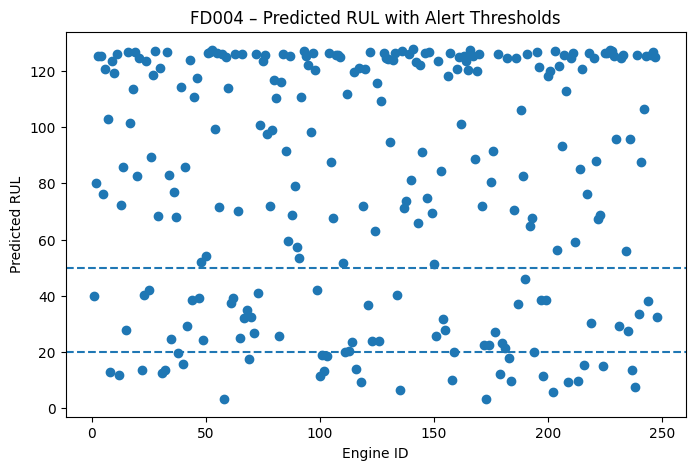

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(fd004_results["Engine_ID"], fd004_results["Predicted_RUL"])
plt.axhline(50, linestyle="--")
plt.axhline(20, linestyle="--")
plt.xlabel("Engine ID")
plt.ylabel("Predicted RUL")
plt.title("FD004 – Predicted RUL with Alert Thresholds")
plt.show()


In [23]:
fd004_results.to_csv("fd004_rul_alert_results.csv", index=False)


In [24]:
from google.colab import drive
drive.mount('/content/drive')

!mkdir -p "/content/drive/MyDrive/FD004_GRU"

!cp best_fd004_gru.pth /content/drive/MyDrive/FD004_GRU/
!cp scaler_fd004.pkl   /content/drive/MyDrive/FD004_GRU/

print("Saved permanently to Drive!")


Mounted at /content/drive
Saved permanently to Drive!


In [25]:
import pickle
import torch
from sklearn.preprocessing import StandardScaler

# Load permanent files for inference
model = GRUModel().to(DEVICE)
model.load_state_dict(torch.load("/content/drive/MyDrive/FD004_GRU/best_fd004_gru.pth",
                                 map_location=DEVICE))
model.eval()

# Load scaler (saved with torch.save earlier)
scaler = torch.load("/content/drive/MyDrive/FD004_GRU/scaler_fd004.pkl", weights_only=False)

print("Future prediction model loaded!")


Future prediction model loaded!


In [26]:
def predict_future_rul(df, seq_len=SEQ_LEN):
    df[selected_features] = scaler.transform(df[selected_features])

    window = df[selected_features].values[-seq_len:]
    if len(window) < seq_len:
        pad = np.repeat(window[0:1], seq_len - len(window), axis=0)
        window = np.vstack([pad, window])

    x = torch.tensor(window[np.newaxis,:,:], dtype=torch.float32).to(DEVICE)
    with torch.no_grad():
        pred = model(x).item()
    return pred


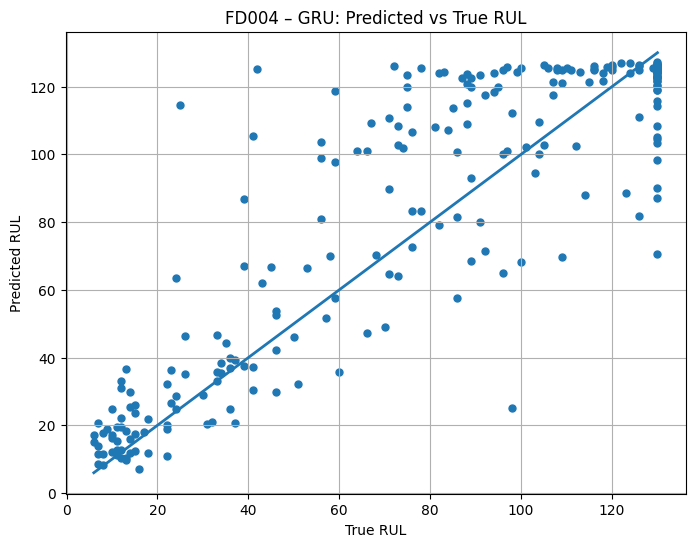

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, preds, s=25)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linewidth=2)

plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("FD004 – GRU: Predicted vs True RUL")
plt.grid(True)
plt.show()


In [28]:
from sklearn.metrics import mean_squared_error
import math

mse = mean_squared_error(y_test, preds)
rmse = math.sqrt(mse)
print("FD004 GRU RMSE:", round(rmse, 4))


FD004 GRU RMSE: 21.4425


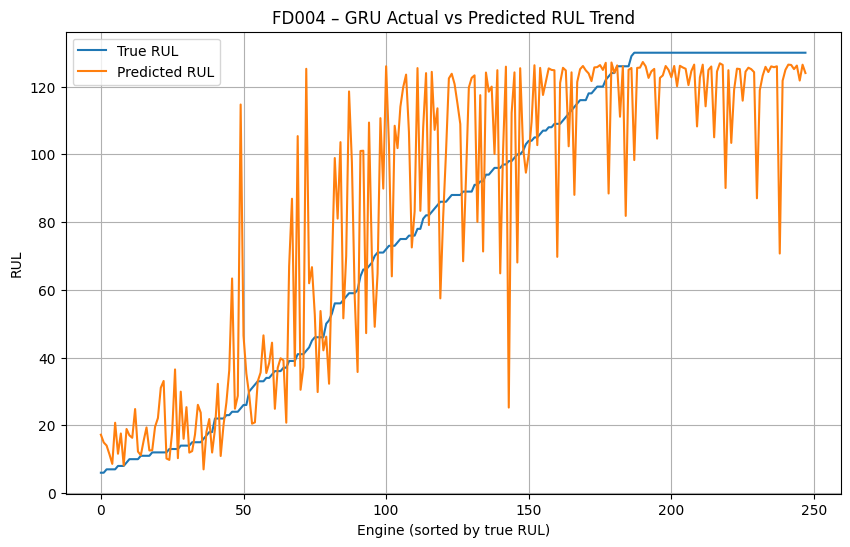

In [29]:
plt.figure(figsize=(10,6))

sorted_idx = y_test.argsort()
plt.plot(y_test[sorted_idx], label="True RUL")
plt.plot(preds[sorted_idx], label="Predicted RUL")

plt.title("FD004 – GRU Actual vs Predicted RUL Trend")
plt.xlabel("Engine (sorted by true RUL)")
plt.ylabel("RUL")
plt.legend()
plt.grid(True)
plt.show()


In [30]:
import os

output_dir = "/content/drive/MyDrive/CMAPSS"
os.makedirs(output_dir, exist_ok=True)

torch.save(model.state_dict(), os.path.join(output_dir, "GRU_FD004.pth"))

print(f"Model saved permanently to {os.path.join(output_dir, 'GRU_FD004.pth')}")


Model saved permanently to /content/drive/MyDrive/CMAPSS/GRU_FD004.pth
